- 3 subt params
- 2 pf params

In [50]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt

import pandas as pd
import seaborn as sns
import os
from statsmodels.stats.multitest import fdrcorrection
# from google.colab import drive
# drive.mount('/content/drive')

from scipy.stats import zscore

import statsmodels.api as sm

from pymer4.models import Lmer, Lm

# !pip install scikit-bio

In [2]:
# mixed_batch_data = pd.read_csv('/content/drive/MyDrive/curvefit_traits_merged_linearpf_onlyneccols.csv', index_col='subID')
mixed_batch_data = pd.read_csv('../../../data/subtlety_playfight_data/curvefit_traits_merged_linearpf_onlyneccols_fight.csv', index_col='subID')
mixed_batch_data.drop('Unnamed: 0', axis=1, inplace=True)
mixed_batch_data

,PSE_subt,range_subt,bias_subt,sigma_subt,PSE_pf,slope_pf,range_pf,bias_pf,social_skill,attn_switch,...,comm,posAffect,negAffect,neuroticism,extraversion,openness,agreeableness,conscientiousness,loneliness,nfriends
subID,,,,,,,,,,,,,,,,,,,,,
30002.0,0.552951,0.900821,0.315504,0.103360,0.513054,0.784286,0.784286,0.452539,21.0,23.0,...,16.000000,20.0,0.0,38.0,28.000000,31.000000,34.0,39.0,56.0,3.0
30004.0,0.276896,0.805834,0.999458,0.076866,0.872907,0.469286,0.469286,0.170256,21.0,20.0,...,15.000000,25.0,11.0,38.0,26.181818,50.000000,50.0,46.0,56.0,3.0
30005.0,0.320583,0.710131,0.861730,0.115353,0.501696,0.842143,0.842143,0.490950,17.0,29.0,...,16.000000,20.0,21.0,51.0,39.000000,40.000000,43.0,19.0,41.0,5.0
30006.0,0.464823,0.989396,0.889572,0.079221,0.741046,0.674587,0.674587,0.000307,8.0,10.0,...,3.000000,25.0,0.0,18.0,41.000000,31.000000,44.0,57.0,30.0,4.0
30008.0,0.325118,0.582252,0.692710,0.172585,0.677591,0.511071,0.511071,0.314366,5.0,15.0,...,12.222222,28.0,4.0,27.0,46.000000,42.545455,46.0,50.0,45.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30344.0,0.361233,0.655715,0.794480,0.135840,0.492859,0.566786,0.566786,0.509343,27.0,18.0,...,16.000000,14.0,0.0,25.0,29.000000,49.000000,35.0,56.0,41.0,6.0
30345.0,0.475067,0.833333,1.000000,0.013915,0.639965,0.781136,0.781136,0.000457,15.0,14.0,...,5.000000,15.0,15.0,36.0,23.000000,37.000000,45.0,54.0,72.0,1.0
30346.0,0.426850,0.999914,0.961644,0.045409,0.412504,0.786429,0.786429,0.822185,16.0,25.0,...,8.000000,27.0,6.0,49.0,36.000000,36.000000,43.0,44.0,56.0,3.0


In [3]:
mixed_batch_data.isna().sum()

PSE_subt             0
range_subt           0
bias_subt            0
sigma_subt           0
PSE_pf               0
slope_pf             0
range_pf             0
bias_pf              0
social_skill         0
attn_switch          0
img                  0
attn_to_det          0
comm                 0
posAffect            0
negAffect            0
neuroticism          0
extraversion         0
openness             0
agreeableness        0
conscientiousness    0
loneliness           0
nfriends             1
dtype: int64

Looks like one subject is missing a value for `nfriends`. Let's just drop them as this will cause headaches later

In [4]:
mixed_batch_data = mixed_batch_data.dropna()
mixed_batch_data.shape

(274, 22)

In [5]:
mixed_batch_data.columns

Index(['PSE_subt', 'range_subt', 'bias_subt', 'sigma_subt', 'PSE_pf',
       'slope_pf', 'range_pf', 'bias_pf', 'social_skill', 'attn_switch', 'img',
       'attn_to_det', 'comm', 'posAffect', 'negAffect', 'neuroticism',
       'extraversion', 'openness', 'agreeableness', 'conscientiousness',
       'loneliness', 'nfriends'],
      dtype='object')

In [6]:
curve_param_cols = [
                  'PSE_subt',
                  'range_subt',
                  'bias_subt',
                  'range_pf',
                  'bias_pf'
                    ]
subt_param_cols = [
                  'PSE_subt',
                  'range_subt',
                  'bias_subt',
                   ]
pf_param_cols = [
                 'range_pf',
                 'bias_pf'
                 ]
trait_cols = [
              'social_skill', 'attn_switch', 'img', 'attn_to_det', 'comm',
              'posAffect',
              'negAffect',
              'neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness',
              'loneliness',
              'nfriends'
       ]

social_cols = [
              'social_skill', 'attn_switch', 'img', 'attn_to_det', 'comm',
              'loneliness',
              'nfriends'
              ]

In [7]:
results_loc= '../../../results/subtlety_playfight_mixed/trait-beh/extra_analyses/'

In [8]:
# first, super important to z-score all the features in order to minimize the impact of different features being measured on different scales (just like PCA)
mixed_batch_data_zscored = mixed_batch_data.apply(zscore)
mixed_batch_data_zscored

,PSE_subt,range_subt,bias_subt,sigma_subt,PSE_pf,slope_pf,range_pf,bias_pf,social_skill,attn_switch,...,comm,posAffect,negAffect,neuroticism,extraversion,openness,agreeableness,conscientiousness,loneliness,nfriends
subID,,,,,,,,,,,,,,,,,,,,,
30002.0,1.587100,1.139946,-2.182466,0.144545,-0.206179,0.740744,0.802900,0.052813,1.249255,1.403779,...,1.044306,-0.214096,-1.031925,0.328778,-1.032702,-1.533105,-1.890716,-0.771265,0.884033,-0.304004
30004.0,-0.836964,0.619923,1.390323,-0.452518,2.089832,-0.732085,-0.731401,-0.970100,1.249255,0.813345,...,0.862296,0.379919,0.470275,0.328778,-1.249254,1.402822,1.569992,0.078101,0.884033,-0.304004
30005.0,-0.453342,0.095984,0.670868,0.414827,-0.278646,1.011263,1.084710,0.192006,0.604630,2.584649,...,1.044306,-0.214096,1.835912,1.543459,0.277433,-0.142403,0.055932,-3.198024,-0.300924,0.449816
30006.0,0.813243,1.624863,0.816307,-0.399448,1.248505,0.227830,0.268579,-1.585944,-0.845776,-1.154772,...,-1.321823,0.379919,-1.031925,-1.539962,0.515640,-1.533105,0.272226,1.412818,-1.169892,0.072906
30008.0,-0.413524,-0.604109,-0.212045,1.704615,0.843637,-0.536710,-0.527871,-0.447886,-1.329245,-0.170714,...,0.356713,0.736328,-0.485670,-0.699029,1.111156,0.250927,0.704815,0.563453,0.015065,0.449816
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30344.0,-0.096389,-0.201924,0.319575,0.876526,-0.335034,-0.276210,-0.256498,0.258657,2.216193,0.419721,...,1.044306,-0.926914,-1.031925,-0.885903,-0.913599,1.248300,-1.674422,1.291480,-0.300924,0.826726
30345.0,0.903194,0.770473,1.393153,-1.871185,0.603566,0.726018,0.787560,-1.585402,0.282318,-0.367525,...,-0.957803,-0.808111,1.016530,0.141904,-1.628218,-0.605970,0.488521,1.048804,2.147987,-1.057824
30346.0,0.479799,1.682444,1.192794,-1.161440,-0.847731,0.750763,0.813338,1.392306,0.443474,1.797403,...,-0.411773,0.617525,-0.212543,1.356585,-0.079876,-0.760493,0.055932,-0.164575,0.884033,-0.304004


# PCA

In [9]:
X = mixed_batch_data_zscored[trait_cols]
X

,social_skill,attn_switch,img,attn_to_det,comm,posAffect,negAffect,neuroticism,extraversion,openness,agreeableness,conscientiousness,loneliness,nfriends
subID,,,,,,,,,,,,,,
30002.0,1.249255,1.403779,-0.345055,-1.202936,1.044306,-0.214096,-1.031925,0.328778,-1.032702,-1.533105,-1.890716,-0.771265,0.884033,-0.304004
30004.0,1.249255,0.813345,-0.345055,-0.143644,0.862296,0.379919,0.470275,0.328778,-1.249254,1.402822,1.569992,0.078101,0.884033,-0.304004
30005.0,0.604630,2.584649,2.396116,0.068214,1.044306,-0.214096,1.835912,1.543459,0.277433,-0.142403,0.055932,-3.198024,-0.300924,0.449816
30006.0,-0.845776,-1.154772,-1.258778,-1.202936,-1.321823,0.379919,-1.031925,-1.539962,0.515640,-1.533105,0.272226,1.412818,-1.169892,0.072906
30008.0,-1.329245,-0.170714,0.340238,0.280072,0.356713,0.736328,-0.485670,-0.699029,1.111156,0.250927,0.704815,0.563453,0.015065,0.449816
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30344.0,2.216193,0.419721,1.939254,0.915647,1.044306,-0.926914,-1.031925,-0.885903,-0.913599,1.248300,-1.674422,1.291480,-0.300924,0.826726
30345.0,0.282318,-0.367525,-1.030347,-0.567361,-0.957803,-0.808111,1.016530,0.141904,-1.628218,-0.605970,0.488521,1.048804,2.147987,-1.057824
30346.0,0.443474,1.797403,-0.801916,0.068214,-0.411773,0.617525,-0.212543,1.356585,-0.079876,-0.760493,0.055932,-0.164575,0.884033,-0.304004


In [ ]:
from sklearn.decomposition import PCA

In [11]:
pca = PCA().fit(X)

In [12]:
results_dir = '../../../results/subtlety_playfight_mixed/trait-beh/extra_analyses' #trait-beh

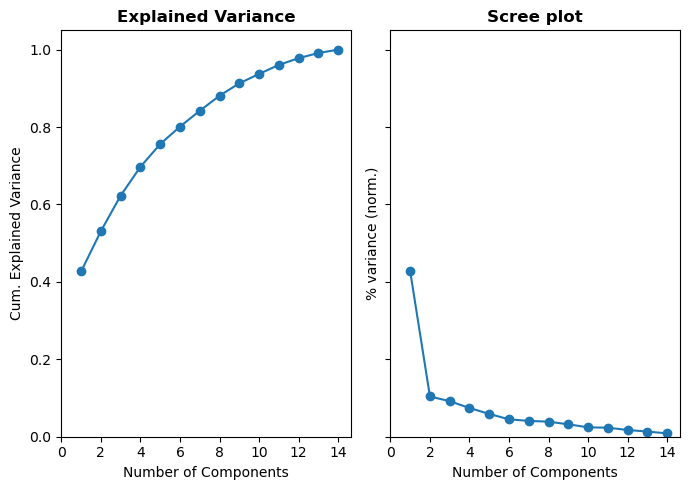

In [13]:
# plotting explained variance
fig,axs = plt.subplots(figsize = (7,5), nrows = 1, ncols = 2,sharey=True,sharex=True)
ax = axs[0]
ax.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='-')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cum. Explained Variance')
ax.set_title('Explained Variance',fontweight='bold')
# ax.grid(True)
ax.set_ylim(0, 1.05)

ax = axs[1]
ax.plot(range(1, len(pca.explained_variance_ratio_) + 1),pca.explained_variance_ratio_, marker='o', linestyle='-')
ax.set_xlabel('Number of Components')
ax.set_ylabel('% variance (norm.)')
ax.set_title('Scree plot',fontweight='bold')
# plt.grid(True)
ax.set_ylim(0, 1.05)
ax.set_xticks(np.arange(0,15,2))

plt.tight_layout()
# plt.savefig(f'{results_dir}/PCA_scree_EV_mixeddesign.png')


In [17]:
cmap = 'BrBG'#'RdBu_r'?

In [18]:
# PC1:5
loadings = pd.DataFrame(pca.components_, columns=X.columns)
loading_values = loadings.iloc[:6,:].values.T#[:,np.newaxis]
loading_values.shape

(14, 6)

In [68]:
yticks

[Text(0, 0.5, 'social'),
 Text(0, 1.5, 'attn'),
 Text(0, 2.5, 'img'),
 Text(0, 3.5, 'attn_to'),
 Text(0, 4.5, 'comm'),
 Text(0, 5.5, 'posAffect'),
 Text(0, 6.5, 'negAffect'),
 Text(0, 7.5, 'neuroticism'),
 Text(0, 8.5, 'extraversion'),
 Text(0, 9.5, 'openness'),
 Text(0, 10.5, 'agreeableness'),
 Text(0, 11.5, 'conscientiousness'),
 Text(0, 12.5, 'loneliness'),
 Text(0, 13.5, 'nfriends')]

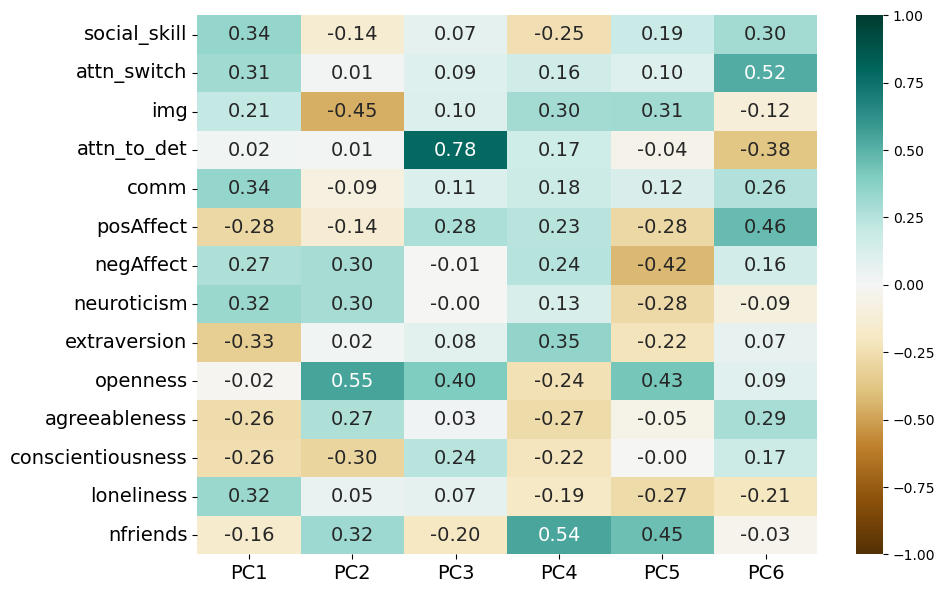

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(loading_values, annot=True, fmt='.2f', cmap=cmap, vmin=-1, vmax=1,annot_kws={"size": 14})
plt.yticks(.5+np.arange(14),loadings.columns,rotation=0,fontsize=14)
plt.xticks([.5,1.5,2.5,3.5,4.5,5.5],[f'PC{i+1}' for i in range(6)], rotation=0,fontsize=14)
yticks = plt.gca().get_yticklabels()
# plt.savefig(f'{results_dir}/PC1_loadings.png',dpi = 300, bbox_inches = 'tight')

In [23]:
# fig, ax = plt.subplots(figsize=(3, 10))
# sns.heatmap(loading_values, annot=True, fmt='.2f', cmap=cmap, vmin=-1, vmax=1,annot_kws={"size": 20})
# plt.yticks(.5+np.arange(14),loadings.columns,rotation=0,fontsize=20)
# plt.xticks([.5],['PC1'], rotation=0,fontsize=20)
# yticks = plt.gca().get_yticklabels()
# plt.gca().set_yticklabels(['_'.join(i.get_text().split('_')[:-1]) if '_' in i.get_text() else i for i in yticks])
# # plt.savefig(f'{results_dir}/PC1_loadings.png',dpi = 300, bbox_inches = 'tight')

In [24]:
pca_sublevel = PCA().fit_transform(X)
pca_sublevel.shape

(274, 14)

In [26]:
df_PCs = pd.DataFrame(columns=[f'PC{i+1}' for i in range(6)],data=pca_sublevel[:,:6])
df_PCs

,PC1,PC2,PC3,PC4,PC5,PC6
0,2.399672,-1.490319,-1.501736,-0.130372,0.163326,0.529903
1,1.312638,1.192440,0.854888,-1.443714,0.355742,1.670362
2,3.464409,0.833372,-0.272321,2.898729,0.254931,1.067488
3,-3.227493,-1.254507,-1.602205,-0.740193,-0.459721,0.009659
4,-1.641404,-0.115014,0.650192,0.741706,0.071656,0.164602
...,...,...,...,...,...,...
269,1.511724,-1.647083,1.481621,-0.076334,3.367148,-0.094038
270,0.995659,0.168150,-0.656496,-2.395709,-1.599842,-0.506646
271,1.013674,0.202807,0.071172,-0.022284,-1.176794,0.902556
272,-3.903645,0.040788,-0.966682,-1.202723,0.027437,0.116941


In [27]:
mixed_batch_data_zscored = pd.concat([mixed_batch_data_zscored.reset_index(),df_PCs],axis=1)

# correlation

In [28]:
curve_param_cols

['PSE_subt', 'range_subt', 'bias_subt', 'range_pf', 'bias_pf']

In [40]:
df_range_beh = pd.DataFrame(data=[[i,mixed_batch_data[i].min(),mixed_batch_data[i].max()] for i in curve_param_cols],columns=['param','min','max'])
df_range_beh['ylabel'] = [i.split('_')[0] for i in df_range_beh['param']]
df_range_beh

,param,min,max,ylabel
0,PSE_subt,0.000000,0.729328,PSE
1,range_subt,0.200238,1.000000,range
2,bias_subt,0.105735,1.000000,bias
3,range_pf,0.014257,0.999900,range
4,bias_pf,0.000101,1.000000,bias


PSE 3
range 5
bias 4
range 5
bias 4


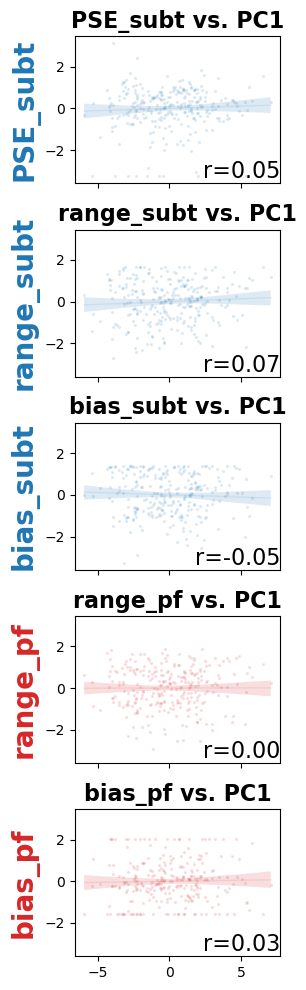

In [47]:
fig, axes = plt.subplots(nrows=len(curve_param_cols), ncols = 1, figsize=(3,10),sharey=True,sharex='col')
all_ps = []
for i,param in enumerate(curve_param_cols):
        x = 'PC1'
        y = param
        r, p = sp.stats.pearsonr(mixed_batch_data_zscored[x], mixed_batch_data_zscored[y])
        all_ps.append(p)

        if p < 0.05:
            # color = 'black'
            weight = 'bold'
            alpha = 1
            fontsize = 20
            linewidth = 1
        else:
            # color = 'gray'
            weight = None
            alpha = .1
            fontsize = 16
            linewidth = 1

        if i <= 2:
            color = 'tab:blue'
        else:
            color = 'tab:red'

        ylabel = df_range_beh.loc[df_range_beh['param']==param,'ylabel'].values[0]
        print(ylabel, len(ylabel))
        axes[i].set_ylabel(ylabel, fontsize=20,color=color,fontweight='bold')


        sns.regplot(data=mixed_batch_data_zscored, x=x, y=y, ax=axes[i], color=color, scatter_kws={'s':2,'alpha':alpha},line_kws={'alpha': alpha, 'linewidth' : linewidth})
        
        axes[i].annotate(f'r={r:.2f}', xy=(1, 0), xycoords = 'axes fraction', weight = weight,fontsize=fontsize,va='bottom',ha='right')

        axes[i].set_xlabel('') 
        

        axes[i].set_title(f'{param} vs. PC1',fontweight='bold',fontsize=16)

fig.tight_layout()
# plt.savefig(f'{results_loc}/trait_beh_all_scatter_long.png', dpi=300, bbox_inches='tight')

In [48]:
fdrcorrection(all_ps)

(array([False, False, False, False, False]),
 array([0.6432343 , 0.6432343 , 0.6432343 , 0.95002054, 0.85008665]))

# Predicting PC1 from curve fit paramsy

## subt + pf

In [53]:
param_list = ['PSE_subt','range_subt','bias_subt','range_pf','bias_pf']

all_ps = np.full((len(param_list)),np.nan) # for MCC

model = Lm(f"PC1 ~ PSE_subt + range_subt + bias_subt + range_pf + bias_pf", data=mixed_batch_data_zscored)
print(model.fit())

for p,param in enumerate(param_list): # for MCC
    all_ps[p] = model.coefs['P-val'][param]

Formula: PC1~PSE_subt+range_subt+bias_subt+range_pf+bias_pf

Family: gaussian	 Estimator: OLS

Std-errors: non-robust	CIs: standard 95%	Inference: parametric 

Number of observations: 274	 R^2: 0.011	 R^2_adj: -0.007

Log-likelihood: -632.354 	 AIC: 1276.707	 BIC: 1298.386

Fixed effects:

            Estimate  2.5_ci  97.5_ci     SE   DF  T-stat  P-val Sig
Intercept      0.000  -0.293    0.293  0.149  268   0.000  1.000    
PSE_subt      -0.068  -0.478    0.343  0.208  268  -0.324  0.746    
range_subt     0.254  -0.143    0.650  0.201  268   1.259  0.209    
bias_subt     -0.219  -0.614    0.177  0.201  268  -1.089  0.277    
range_pf      -0.020  -0.363    0.323  0.174  268  -0.113  0.910    
bias_pf        0.085  -0.210    0.379  0.150  268   0.567  0.571    


## only subt 

In [55]:
param_list = ['PSE_subt','range_subt','bias_subt']

all_ps = np.full((len(param_list)),np.nan) # for MCC

model = Lm(f"PC1 ~ PSE_subt + range_subt + bias_subt ", data=mixed_batch_data_zscored)
print(model.fit())

for p,param in enumerate(param_list): # for MCC
    all_ps[p] = model.coefs['P-val'][param]

Formula: PC1~PSE_subt+range_subt+bias_subt

Family: gaussian	 Estimator: OLS

Std-errors: non-robust	CIs: standard 95%	Inference: parametric 

Number of observations: 274	 R^2: 0.010	 R^2_adj: -0.001

Log-likelihood: -632.522 	 AIC: 1273.045	 BIC: 1287.497

Fixed effects:

            Estimate  2.5_ci  97.5_ci     SE   DF  T-stat  P-val Sig
Intercept      0.000  -0.292    0.292  0.148  270   0.000  1.000    
PSE_subt      -0.072  -0.481    0.336  0.207  270  -0.348  0.728    
range_subt     0.244  -0.133    0.620  0.191  270   1.274  0.204    
bias_subt     -0.218  -0.597    0.161  0.192  270  -1.134  0.258    


## only pf

In [56]:
param_list = ['range_pf','bias_pf']

all_ps = np.full((len(param_list)),np.nan) # for MCC

model = Lm(f"PC1 ~  range_pf + bias_pf", data=mixed_batch_data_zscored)
print(model.fit())

for p,param in enumerate(param_list): # for MCC
    all_ps[p] = model.coefs['P-val'][param]

Formula: PC1~range_pf+bias_pf

Family: gaussian	 Estimator: OLS

Std-errors: non-robust	CIs: standard 95%	Inference: parametric 

Number of observations: 274	 R^2: 0.001	 R^2_adj: -0.007

Log-likelihood: -633.793 	 AIC: 1273.586	 BIC: 1284.425

Fixed effects:

           Estimate  2.5_ci  97.5_ci     SE   DF  T-stat  P-val Sig
Intercept     0.000  -0.292    0.292  0.149  271   0.000  1.000    
range_pf      0.007  -0.286    0.299  0.149  271   0.045  0.964    
bias_pf       0.061  -0.232    0.354  0.149  271   0.410  0.682    


- in all 3 models, none of the terms are significant

# PCs 1-6

In [57]:
PC_cols = [f'PC{i+1}' for i in range(6)]
PC_cols

['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6']

PSE 3
range 5
bias 4
range 5
bias 4


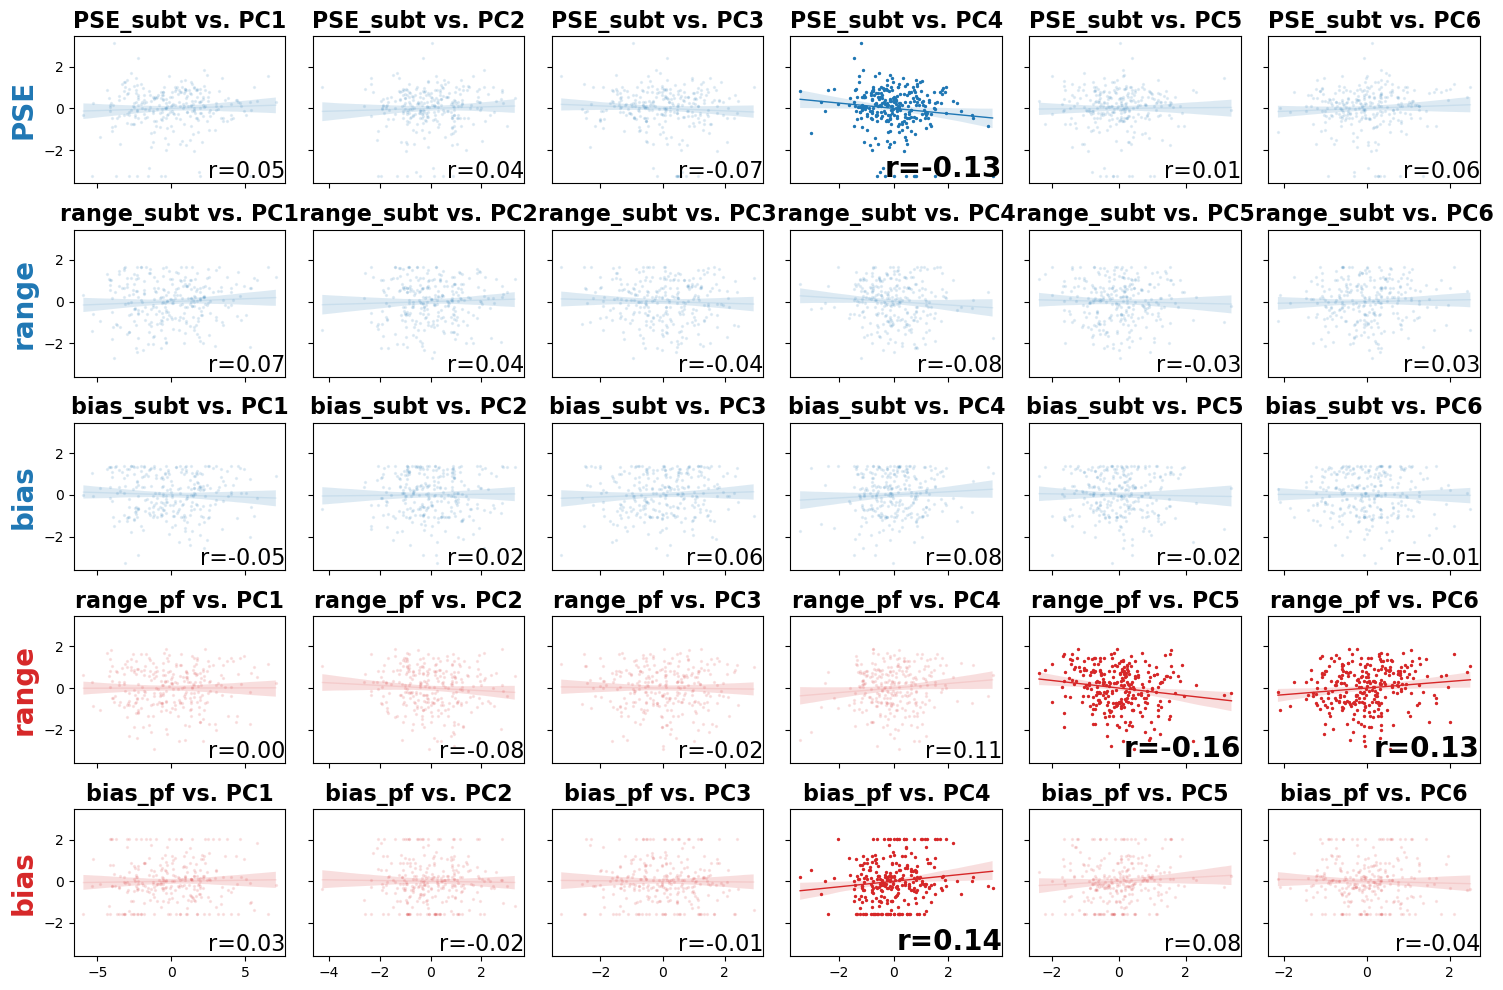

In [58]:
fig, axes = plt.subplots(nrows=len(curve_param_cols), ncols = len(PC_cols), figsize=(15,10),sharey=True,sharex='col')

all_ps = []

for i,param in enumerate(curve_param_cols):
    for j,trait in enumerate(PC_cols):
        x = trait
        y = param
        r, p = sp.stats.pearsonr(mixed_batch_data_zscored[x], mixed_batch_data_zscored[y])
        all_ps.append(p)

        if p < 0.05:
            # color = 'black'
            weight = 'bold'
            alpha = 1
            fontsize = 20
            linewidth = 1
        else:
            # color = 'gray'
            weight = None
            alpha = .1
            fontsize = 16
            linewidth = 1

        if i <= 2:
            color = 'tab:blue'
        else:
            color = 'tab:red'


        sns.regplot(data=mixed_batch_data_zscored, x=x, y=y, ax=axes[i,j], color=color, scatter_kws={'s':2,'alpha':alpha},line_kws={'alpha': alpha, 'linewidth' : linewidth})
        
        axes[i,j].annotate(f'r={r:.2f}', xy=(1, 0), xycoords = 'axes fraction', weight = weight,fontsize=fontsize,va='bottom',ha='right')

        axes[i,j].set_xlabel('') 
        
        if j == 0:
            ylabel = df_range_beh.loc[df_range_beh['param']==param,'ylabel'].values[0]
            print(ylabel, len(ylabel))
            axes[i,j].set_ylabel(ylabel, fontsize=20,color=color,fontweight='bold')
        else:
            axes[i,j].set_ylabel('')


        axes[i,j].set_title(f'{param} vs. {trait}',fontweight='bold',fontsize=16)
        
        # row = df_range_traits['trait'] == trait
        # xmin,xmax = df_range_traits.loc[row,'min'].values[0],df_range_traits.loc[row,'max'].values[0]
        # axes[i,j].set_xlim(xmin,xmax)
        # axes[i,j].set_xticks(df_range_traits.loc[row,'tickends'].values[0])

fig.tight_layout()
# plt.savefig(f'{results_loc}/trait_beh_all_scatter_long.png', dpi=300, bbox_inches='tight')

In [39]:
fdrcorrection(all_ps)

(array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]),
 array([0.77188115, 0.82786245, 0.74138574, 0.27783806, 0.90566373,
        0.77188115, 0.74138574, 0.82786245, 0.82786245, 0.70768741,
        0.89591029, 0.90347354, 0.77188115, 0.90358781, 0.77188115,
        0.70768741, 0.90358781, 0.92763015, 0.95002054, 0.70768741,
        0.90358781, 0.3946225 , 0.18856753, 0.27783806, 0.90358781,
        0.90358781, 0.90358781, 0.27783806, 0.70768741, 0.85780061]))

# Predicting each PC

## subt + pf

In [92]:
param_list = ['PSE_subt','range_subt','bias_subt','range_pf','bias_pf']

all_ps = np.full((len(PC_cols),len(param_list)),np.nan) # for MCC
for t,trait in enumerate(PC_cols):
    print(f'\nTRAIT {trait}')
    model = Lm(f"{trait} ~ PSE_subt + range_subt + bias_subt + range_pf + bias_pf", data=mixed_batch_data_zscored)
    print(model.fit())

    for p,param in enumerate(param_list): # for MCC
        all_ps[t,p] = model.coefs['P-val'][param]


TRAIT PC1
Formula: PC1~PSE_subt+range_subt+bias_subt+range_pf+bias_pf

Family: gaussian	 Estimator: OLS

Std-errors: non-robust	CIs: standard 95%	Inference: parametric 

Number of observations: 274	 R^2: 0.011	 R^2_adj: -0.007

Log-likelihood: -632.354 	 AIC: 1276.707	 BIC: 1298.386

Fixed effects:

            Estimate  2.5_ci  97.5_ci     SE   DF  T-stat  P-val Sig
Intercept      0.000  -0.293    0.293  0.149  268   0.000  1.000    
PSE_subt      -0.068  -0.478    0.343  0.208  268  -0.324  0.746    
range_subt     0.254  -0.143    0.650  0.201  268   1.259  0.209    
bias_subt     -0.219  -0.614    0.177  0.201  268  -1.089  0.277    
range_pf      -0.020  -0.363    0.323  0.174  268  -0.113  0.910    
bias_pf        0.085  -0.210    0.379  0.150  268   0.567  0.571    

TRAIT PC2
Formula: PC2~PSE_subt+range_subt+bias_subt+range_pf+bias_pf

Family: gaussian	 Estimator: OLS

Std-errors: non-robust	CIs: standard 95%	Inference: parametric 

Number of observations: 274	 R^2: 0.016	 R^2

In [93]:
## MCC
result_bool = np.full_like(all_ps,np.nan)
corrected_p = np.full_like(all_ps,np.nan)
for p, param in enumerate(param_list):
    result_bool[:,p], corrected_p[:,p] = fdrcorrection(all_ps[:,p])
    print(param, np.where(result_bool[:,p])[0], np.array(PC_cols)[np.where(result_bool[:,p])[0]])
# i.e., openness-range_pf is the only relationship that survives MCC

PSE_subt [] []
range_subt [] []
bias_subt [] []
range_pf [3 4 5] ['PC4' 'PC5' 'PC6']
bias_pf [] []


# Only subt

In [94]:
param_list = ['PSE_subt','range_subt','bias_subt']

all_ps = np.full((len(PC_cols),len(param_list)),np.nan) # for MCC
for t,trait in enumerate(PC_cols):
    print(f'\nTRAIT {trait}')
    model = Lm(f"{trait} ~ PSE_subt + range_subt + bias_subt", data=mixed_batch_data_zscored)
    print(model.fit())

    for p,param in enumerate(param_list): # for MCC
        all_ps[t,p] = model.coefs['P-val'][param]


TRAIT PC1
Formula: PC1~PSE_subt+range_subt+bias_subt

Family: gaussian	 Estimator: OLS

Std-errors: non-robust	CIs: standard 95%	Inference: parametric 

Number of observations: 274	 R^2: 0.010	 R^2_adj: -0.001

Log-likelihood: -632.522 	 AIC: 1273.045	 BIC: 1287.497

Fixed effects:

            Estimate  2.5_ci  97.5_ci     SE   DF  T-stat  P-val Sig
Intercept      0.000  -0.292    0.292  0.148  270   0.000  1.000    
PSE_subt      -0.072  -0.481    0.336  0.207  270  -0.348  0.728    
range_subt     0.244  -0.133    0.620  0.191  270   1.274  0.204    
bias_subt     -0.218  -0.597    0.161  0.192  270  -1.134  0.258    

TRAIT PC2
Formula: PC2~PSE_subt+range_subt+bias_subt

Family: gaussian	 Estimator: OLS

Std-errors: non-robust	CIs: standard 95%	Inference: parametric 

Number of observations: 274	 R^2: 0.003	 R^2_adj: -0.008

Log-likelihood: -439.810 	 AIC: 887.621	 BIC: 902.073

Fixed effects:

            Estimate  2.5_ci  97.5_ci     SE   DF  T-stat  P-val Sig
Intercept     -0.0

In [96]:
## MCC
result_bool = np.full_like(all_ps,np.nan)
corrected_p = np.full_like(all_ps,np.nan)
for p, param in enumerate(param_list):
    result_bool[:,p], corrected_p[:,p] = fdrcorrection(all_ps[:,p])
    print(param, np.where(result_bool[:,p])[0], np.array(PC_cols)[np.where(result_bool[:,p])[0]])
# i.e., openness-range_pf is the only relationship that survives MCC

PSE_subt [] []
range_subt [] []
bias_subt [] []


# only pf

In [97]:
param_list = ['range_pf','bias_pf']

all_ps = np.full((len(PC_cols),len(param_list)),np.nan) # for MCC
for t,trait in enumerate(PC_cols):
    print(f'\nTRAIT {trait}')
    model = Lm(f"{trait} ~ range_pf + bias_pf", data=mixed_batch_data_zscored)
    print(model.fit())

    for p,param in enumerate(param_list): # for MCC
        all_ps[t,p] = model.coefs['P-val'][param]


TRAIT PC1
Formula: PC1~range_pf+bias_pf

Family: gaussian	 Estimator: OLS

Std-errors: non-robust	CIs: standard 95%	Inference: parametric 

Number of observations: 274	 R^2: 0.001	 R^2_adj: -0.007

Log-likelihood: -633.793 	 AIC: 1273.586	 BIC: 1284.425

Fixed effects:

           Estimate  2.5_ci  97.5_ci     SE   DF  T-stat  P-val Sig
Intercept     0.000  -0.292    0.292  0.149  271   0.000  1.000    
range_pf      0.007  -0.286    0.299  0.149  271   0.045  0.964    
bias_pf       0.061  -0.232    0.354  0.149  271   0.410  0.682    

TRAIT PC2
Formula: PC2~range_pf+bias_pf

Family: gaussian	 Estimator: OLS

Std-errors: non-robust	CIs: standard 95%	Inference: parametric 

Number of observations: 274	 R^2: 0.006	 R^2_adj: -0.001

Log-likelihood: -439.428 	 AIC: 884.857	 BIC: 895.696

Fixed effects:

           Estimate  2.5_ci  97.5_ci     SE   DF  T-stat  P-val Sig
Intercept    -0.000  -0.144    0.144  0.073  271  -0.000  1.000    
range_pf     -0.090  -0.234    0.054  0.073  271  

In [98]:
## MCC
result_bool = np.full_like(all_ps,np.nan)
corrected_p = np.full_like(all_ps,np.nan)
for p, param in enumerate(param_list):
    result_bool[:,p], corrected_p[:,p] = fdrcorrection(all_ps[:,p])
    print(param, np.where(result_bool[:,p])[0], np.array(PC_cols)[np.where(result_bool[:,p])[0]])
# i.e., openness-range_pf is the only relationship that survives MCC

range_pf [4] ['PC5']
bias_pf [] []


# Predicting curve fit params

In [99]:
param_list = ['PSE_subt','range_subt','bias_subt','range_pf','bias_pf']

all_ps = np.full((len(PC_cols),len(param_list)),np.nan) # for MCC
for iparam,param in enumerate(param_list):
    print(f'\nPARAM {param}')
    model = Lm(f"{param} ~ PC1 + PC2 + PC3 + PC4 + PC5 + PC6", data=mixed_batch_data_zscored)
    print(model.fit())

    for pc,PC in enumerate(PC_cols): # for MCC
        all_ps[pc, iparam] = model.coefs['P-val'][PC]


PARAM PSE_subt
Formula: PSE_subt~PC1+PC2+PC3+PC4+PC5+PC6

Family: gaussian	 Estimator: OLS

Std-errors: non-robust	CIs: standard 95%	Inference: parametric 

Number of observations: 274	 R^2: 0.029	 R^2_adj: 0.007

Log-likelihood: -384.753 	 AIC: 783.505	 BIC: 808.797

Fixed effects:

           Estimate  2.5_ci  97.5_ci     SE   DF  T-stat  P-val Sig
Intercept    -0.000  -0.119    0.119  0.060  267  -0.000  1.000    
PC1           0.021  -0.027    0.070  0.025  267   0.872  0.384    
PC2           0.034  -0.064    0.133  0.050  267   0.684  0.495    
PC3          -0.059  -0.164    0.046  0.053  267  -1.106  0.270    
PC4          -0.128  -0.244   -0.011  0.059  267  -2.156  0.032   *
PC5           0.013  -0.118    0.144  0.066  267   0.196  0.844    
PC6           0.070  -0.080    0.219  0.076  267   0.919  0.359    

PARAM range_subt
Formula: range_subt~PC1+PC2+PC3+PC4+PC5+PC6

Family: gaussian	 Estimator: OLS

Std-errors: non-robust	CIs: standard 95%	Inference: parametric 

Number o

In [ ]:
all_ps.shape # PC x iparam

(6, 5)

In [100]:
result_bool = np.full_like(all_ps,np.nan)
corrected_p = np.full_like(all_ps,np.nan)
for pc, PC in enumerate(PC_cols): # MCC one PC at a time
    result_bool[pc,:], corrected_p[pc,:] = fdrcorrection(all_ps[pc,:]) # MCC across all params for one PC (regressor) at a time
    print(PC, np.where(result_bool[pc,:])[0], np.array(param_list)[np.where(result_bool[pc,:])[0]])

PC1 [] []
PC2 [] []
PC3 [] []
PC4 [] []
PC5 [3] ['range_pf']
PC6 [] []
